In [2]:
# =============================================================
# Cell 1: Install and Import Libraries
# =============================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version: {torch.__version__}')
print(f'Device: {device}')
print('Libraries loaded successfully.')


PyTorch version: 2.11.0+cpu
Device: cpu
Libraries loaded successfully.


In [6]:
from google.colab import files
uploaded = files.upload()

Saving pmsm_small.csv to pmsm_small.csv
Saving dataset_D_v2.csv to dataset_D_v2.csv
Saving dataset_C_final.csv to dataset_C_final.csv
Saving dataset_B_final.csv to dataset_B_final.csv
Saving dataset_A_v2.csv to dataset_A_v2.csv


In [8]:
import os
for f in os.listdir('/content'):
    if f.endswith('.csv'):
        print(f)

pmsm_small.csv
dataset_A_v2.csv
dataset_C_final.csv
dataset_B_final.csv
dataset_D_v2.csv


In [10]:
import pandas as pd

df_A = pd.read_csv('dataset_A_v2.csv')
df_B = pd.read_csv('dataset_B_final.csv')
df_C = pd.read_csv('dataset_C_final.csv')
df_D = pd.read_csv('dataset_D_v2.csv')
df_P = pd.read_csv('pmsm_small.csv')

print('=== DATASETS LOADED ===')
print(f'A: {df_A.shape} | Temp: {df_A["temperature"].min():.1f} to {df_A["temperature"].max():.1f}C')
print(f'B: {df_B.shape} | Temp: {df_B["temperature"].min():.1f} to {df_B["temperature"].max():.1f}C')
print(f'C: {df_C.shape} | Temp: {df_C["temperature"].min():.1f} to {df_C["temperature"].max():.1f}C')
print(f'D: {df_D.shape} | Temp: {df_D["temperature"].min():.1f} to {df_D["temperature"].max():.1f}C')
print(f'PMSM: {df_P.shape}')

=== DATASETS LOADED ===
A: (2001, 7) | Temp: 25.0 to 48.8C
B: (2001, 7) | Temp: 25.0 to 50.2C
C: (1001, 7) | Temp: 25.0 to 37.8C
D: (2001, 7) | Temp: 25.0 to 48.8C
PMSM: (13309, 13)


In [11]:
print('PMSM Columns:', df_P.columns.tolist())
print('Profile IDs:', sorted(df_P['profile_id'].unique()))
print(f'Profile 6 rows: {len(df_P[df_P["profile_id"]==6])}')
print(f'Profile 4 rows: {len(df_P[df_P["profile_id"]==4])}')
print(f'PM temp range: {df_P["pm"].min():.1f} to {df_P["pm"].max():.1f}C')

PMSM Columns: ['u_q', 'coolant', 'stator_winding', 'u_d', 'stator_tooth', 'motor_speed', 'i_d', 'i_q', 'pm', 'stator_yoke', 'ambient', 'torque', 'profile_id']
Profile IDs: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(23), np.int64(24), np.int64(26), np.int64(27), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(36), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(

In [12]:
# =============================================================
# Cell 3: Prepare SPIM Data
# Description: Extract features and target, normalize using
# MinMaxScaler fitted on Dataset A only. Convert to tensors.
# Features: speed, current_main, current_aux, torque, time
# Target: temperature
# =============================================================

import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

features = ['speed_rpm', 'current_main', 'current_aux', 'torque', 'time']
target   = 'temperature'

X_A = df_A[features].values;  y_A = df_A[target].values.reshape(-1,1)
X_B = df_B[features].values;  y_B = df_B[target].values.reshape(-1,1)
X_C = df_C[features].values;  y_C = df_C[target].values.reshape(-1,1)
X_D = df_D[features].values;  y_D = df_D[target].values.reshape(-1,1)

# Fit scalers on Dataset A only
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
scaler_X.fit(X_A)
scaler_y.fit(y_A)

def to_tensor(X, y):
    return (torch.tensor(scaler_X.transform(X), dtype=torch.float32).to(device),
            torch.tensor(scaler_y.transform(y), dtype=torch.float32).to(device))

X_A_t, y_A_t = to_tensor(X_A, y_A)
X_B_t, y_B_t = to_tensor(X_B, y_B)
X_C_t, y_C_t = to_tensor(X_C, y_C)
X_D_t, y_D_t = to_tensor(X_D, y_D)

print('=== DATA PREPARATION COMPLETE ===')
print(f'Scaler fitted on Dataset A only')
print(f'Feature range after scaling: 0 to 1')
print(f'Temperature scaler: {scaler_y.data_min_[0]:.2f} to {scaler_y.data_max_[0]:.2f} C')
print(f'Tensors ready on device: {device}')

=== DATA PREPARATION COMPLETE ===
Scaler fitted on Dataset A only
Feature range after scaling: 0 to 1
Temperature scaler: 25.00 to 48.80 C
Tensors ready on device: cpu


In [13]:
# =============================================================
# Cell 4: Model Architecture and Evaluation Function
# Description: Shared feedforward neural network architecture
# used for both DNN and PINN. Identical in all aspects except
# the loss function used during training.
# Architecture: 5 -> 20 -> 20 -> 10 -> 1 (tanh activations)
# =============================================================

import torch.nn as nn

class ThermalNN(nn.Module):
    def __init__(self, in_dim=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 20), nn.Tanh(),
            nn.Linear(20, 20),     nn.Tanh(),
            nn.Linear(20, 10),     nn.Tanh(),
            nn.Linear(10, 1)
        )
    def forward(self, x):
        return self.net(x)

def evaluate(model, X, y, scaler_y):
    """
    Evaluate model performance.
    Returns MAE, RMSE, R2, predictions, true values
    all in original temperature scale (degrees C).
    """
    model.eval()
    with torch.no_grad():
        pred_n = model(X).cpu().numpy()
        true_n = y.cpu().numpy()
    pred = scaler_y.inverse_transform(pred_n)
    true = scaler_y.inverse_transform(true_n)
    mae  = np.mean(np.abs(pred - true))
    rmse = np.sqrt(np.mean((pred - true)**2))
    ss_r = np.sum((true - pred)**2)
    ss_t = np.sum((true - np.mean(true))**2)
    r2   = 1 - ss_r/ss_t
    return mae, rmse, r2, pred, true

print('Model architecture and evaluation function ready.')
print(f'Network: 5 -> 20 -> 20 -> 10 -> 1 (tanh)')
print(f'Parameters: {sum(p.numel() for p in ThermalNN().parameters())} trainable weights')

Model architecture and evaluation function ready.
Network: 5 -> 20 -> 20 -> 10 -> 1 (tanh)
Parameters: 761 trainable weights


In [14]:
# =============================================================
# Cell 5: Physics Loss Function
# Description: Implements the first-order thermal ODE as a
# physics residual loss term for the PINN.
#
# Governing equation (Calasan et al., 2021):
# C_th * dT/dt = I_main^2 * R_main(T)
#              + I_aux^2  * R_aux(T)
#              + B * omega        (friction loss)
#              - h * (T - T_amb)  (convective cooling)
#
# Motor Parameters (from manufacturer datasheet):
# R_main = 2.02 Ohm, R_aux = 7.14 Ohm
# alpha  = 0.00393 /degC (copper temp coefficient)
# C_th   = 25000 J/degC, h = 28 W/degC
# B      = 0.0005 Nm.s/rad (bearing loss coefficient)
# T_amb  = 25 degC
# =============================================================

def physics_loss_spim(model, X, scaler_y, scaler_X,
                      C_TH=25000.0, H=28.0,
                      R_MAIN=2.02, R_AUX=7.14,
                      ALPHA=0.00393, T_REF=25.0,
                      T_AMB=25.0, B_friction=0.0005):

    X_var = X.clone().detach().requires_grad_(True)
    T_norm = model(X_var)

    # Automatic differentiation for dT/dt
    dT_dt_norm = torch.autograd.grad(
        T_norm.sum(), X_var, create_graph=True
    )[0][:, 4:5]

    # Denormalize temperature
    T_min  = scaler_y.data_min_[0]
    T_max  = scaler_y.data_max_[0]
    T_pred = T_norm * (T_max - T_min) + T_min

    # Denormalize signals
    I_main = X[:, 1:2] * scaler_X.data_max_[1]
    I_aux  = X[:, 2:3] * scaler_X.data_max_[2]
    omega  = X[:, 0:1] * scaler_X.data_max_[0] * (2 * np.pi / 60)

    # Temperature-dependent resistance R(T) = R0[1 + alpha(T-T_ref)]
    R_main_T = R_MAIN * (1 + ALPHA * (T_pred - T_REF))
    R_aux_T  = R_AUX  * (1 + ALPHA * (T_pred - T_REF))

    # Heat sources and sink
    P_copper   = I_main**2 * R_main_T + I_aux**2 * R_aux_T
    P_friction = B_friction * omega
    P_cooling  = H * (T_pred - T_AMB)

    # Physical time derivative
    t_scale = scaler_X.data_max_[4] - scaler_X.data_min_[4]
    dT_dt   = dT_dt_norm * (T_max - T_min) / t_scale

    # Physics residual
    residual = C_TH * dT_dt - (P_copper + P_friction - P_cooling)

    # Normalize residual to keep loss scale manageable
    residual_normalized = residual / 1000.0

    return torch.mean(residual_normalized**2)

print('Physics loss function ready.')
print('Includes: copper losses + friction losses + convective cooling')
print('Reference: Calasan et al. (2021), Applied Sciences')

Physics loss function ready.
Includes: copper losses + friction losses + convective cooling
Reference: Calasan et al. (2021), Applied Sciences


In [15]:
# =============================================================
# Cell 6: DNN Training
# Description: Train unconstrained feedforward DNN on Dataset A
# only. No physics constraint. Pure data-driven baseline.
# Epochs: 3000, Optimizer: Adam, LR: 0.001, Loss: MSE
# =============================================================

torch.manual_seed(SEED)
dnn = ThermalNN(in_dim=5).to(device)
opt_dnn = torch.optim.Adam(dnn.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
losses_dnn = []

for ep in range(3000):
    dnn.train()
    opt_dnn.zero_grad()
    loss = loss_fn(dnn(X_A_t), y_A_t)
    loss.backward()
    opt_dnn.step()
    losses_dnn.append(loss.item())
    if ep % 500 == 0:
        print(f'DNN Epoch {ep:4d}: Loss = {loss.item():.6f}')

# Evaluate on all datasets
print('\n=== DNN EVALUATION ===')
mae_dnn, rmse_dnn, r2_dnn = {}, {}, {}
datasets = {'A': (X_A_t, y_A_t),
            'B': (X_B_t, y_B_t),
            'C': (X_C_t, y_C_t),
            'D': (X_D_t, y_D_t)}

for name, (X, y) in datasets.items():
    mae, rmse, r2, _, _ = evaluate(dnn, X, y, scaler_y)
    mae_dnn[name]  = mae
    rmse_dnn[name] = rmse
    r2_dnn[name]   = r2
    print(f'Dataset {name}: MAE={mae:.4f}°C | RMSE={rmse:.4f}°C | R²={r2:.4f}')

DNN Epoch    0: Loss = 0.395774
DNN Epoch  500: Loss = 0.000188
DNN Epoch 1000: Loss = 0.000074
DNN Epoch 1500: Loss = 0.000030
DNN Epoch 2000: Loss = 0.000018
DNN Epoch 2500: Loss = 0.000014

=== DNN EVALUATION ===
Dataset A: MAE=0.0660°C | RMSE=0.0771°C | R²=0.9999
Dataset B: MAE=0.4338°C | RMSE=0.5605°C | R²=0.9939
Dataset C: MAE=0.0629°C | RMSE=0.0735°C | R²=0.9996
Dataset D: MAE=0.1276°C | RMSE=0.1609°C | R²=0.9994


In [16]:
# =============================================================
# Cell 7: PINN Training
# Description: Train physics-informed neural network on Dataset A.
# Same architecture as DNN with additional physics residual loss
# based on the first-order thermal ODE (Cell 5).
# Lambda = 1e-4 (physics loss weight)
# =============================================================

LAMBDA_P = 1e-4

torch.manual_seed(SEED)
pinn = ThermalNN(in_dim=5).to(device)
opt_pinn = torch.optim.Adam(pinn.parameters(), lr=1e-3)
losses_pinn = []

for ep in range(3000):
    pinn.train()
    opt_pinn.zero_grad()
    X_A_t.requires_grad_(True)
    pred   = pinn(X_A_t)
    data_l = loss_fn(pred, y_A_t)
    phys_l = physics_loss_spim(pinn, X_A_t, scaler_y, scaler_X)
    total  = data_l + LAMBDA_P * phys_l
    total.backward()
    opt_pinn.step()
    losses_pinn.append(total.item())
    if ep % 500 == 0:
        print(f'PINN Epoch {ep:4d}: Data={data_l.item():.6f} | '
              f'Phys={phys_l.item():.4f} | Total={total.item():.6f}')

# Evaluate on all datasets
print('\n=== PINN EVALUATION ===')
mae_pinn, rmse_pinn, r2_pinn = {}, {}, {}

for name, (X, y) in datasets.items():
    mae, rmse, r2, _, _ = evaluate(pinn, X, y, scaler_y)
    mae_pinn[name]  = mae
    rmse_pinn[name] = rmse
    r2_pinn[name]   = r2
    print(f'Dataset {name}: MAE={mae:.4f}°C | RMSE={rmse:.4f}°C | R²={r2:.4f}')

PINN Epoch    0: Data=0.395774 | Phys=0.7044 | Total=0.395844
PINN Epoch  500: Data=0.000193 | Phys=5.7741 | Total=0.000770
PINN Epoch 1000: Data=0.000078 | Phys=5.7515 | Total=0.000653
PINN Epoch 1500: Data=0.000036 | Phys=5.7415 | Total=0.000610
PINN Epoch 2000: Data=0.000026 | Phys=5.7383 | Total=0.000600
PINN Epoch 2500: Data=0.000023 | Phys=5.7364 | Total=0.000596

=== PINN EVALUATION ===
Dataset A: MAE=0.0785°C | RMSE=0.1081°C | R²=0.9997
Dataset B: MAE=0.4710°C | RMSE=0.6161°C | R²=0.9926
Dataset C: MAE=0.0786°C | RMSE=0.1075°C | R²=0.9991
Dataset D: MAE=0.1313°C | RMSE=0.1670°C | R²=0.9994


In [18]:
import os
for f in os.listdir('/content'):
    if f.endswith('.csv'):
        print(f)

pmsm_small.csv
dataset_A_v2.csv
dataset_C_final.csv
dataset_B_final.csv
dataset_D_v2.csv


In [21]:
from google.colab import files
uploaded = files.upload()

Saving dataset_B2.csv to dataset_B2.csv


In [22]:
import os
for f in os.listdir('/content'):
    if 'B2' in f or 'b2' in f:
        print(f'Found: {f}')
print('Check complete')

Found: dataset_B2.csv
Check complete


In [23]:
# Load B2
df_B2 = pd.read_csv('dataset_B2.csv')
print(f'Dataset B2: {df_B2.shape}')
print(f'Temperature: {df_B2["temperature"].min():.1f} to {df_B2["temperature"].max():.1f}C')
print(f'Ambient: {df_B2["ambient"].min():.1f} to {df_B2["ambient"].max():.1f}C')

# Prepare tensors
X_B2 = df_B2[features].values
y_B2 = df_B2[target].values.reshape(-1, 1)
X_B2_t = torch.tensor(scaler_X.transform(X_B2), dtype=torch.float32).to(device)
y_B2_t  = torch.tensor(scaler_y.transform(y_B2),  dtype=torch.float32).to(device)

# Evaluate
mae_dnn_B2,  rmse_dnn_B2,  r2_dnn_B2,  _, _ = evaluate(dnn,  X_B2_t, y_B2_t, scaler_y)
mae_pinn_B2, rmse_pinn_B2, r2_pinn_B2, _, _ = evaluate(pinn, X_B2_t, y_B2_t, scaler_y)

print('\n=== DATASET B2 RESULTS ===')
print(f'DNN:  MAE={mae_dnn_B2:.4f}°C | RMSE={rmse_dnn_B2:.4f}°C | R²={r2_dnn_B2:.4f}')
print(f'PINN: MAE={mae_pinn_B2:.4f}°C | RMSE={rmse_pinn_B2:.4f}°C | R²={r2_pinn_B2:.4f}')
winner = 'DNN' if mae_dnn_B2 < mae_pinn_B2 else 'PINN'
print(f'Winner: {winner}')

Dataset B2: (2001, 7)
Temperature: 25.0 to 52.4C
Ambient: 40.0 to 40.0C

=== DATASET B2 RESULTS ===
DNN:  MAE=1.8500°C | RMSE=2.1196°C | R²=0.9270
PINN: MAE=1.8705°C | RMSE=2.1526°C | R²=0.9247
Winner: DNN


In [24]:
# =============================================================
# Cell 9: PMSM Benchmark Validation
# Description: Validate diagnostic pattern on real test bench
# data from a 52kW automotive PMSM (Paderborn University).
# Train on Profile 6, Test on Profile 4 (distribution shift).
# Features: motor_speed, i_q, torque, ambient, coolant
# Target: pm (permanent magnet temperature)
# Reference: Kirchgässner et al. (2021)
# =============================================================

# Prepare PMSM data
train_id, test_id = 6, 4
features_pmsm = ['motor_speed', 'i_q', 'torque', 'ambient', 'coolant']
target_pmsm   = 'pm'

df_train = df_P[df_P['profile_id'] == train_id].copy()
df_test  = df_P[df_P['profile_id'] == test_id].copy()

X_tr = df_train[features_pmsm].values
y_tr = df_train[target_pmsm].values.reshape(-1, 1)
X_te = df_test[features_pmsm].values
y_te = df_test[target_pmsm].values.reshape(-1, 1)

sc_X_p = MinMaxScaler()
sc_y_p = MinMaxScaler()
sc_X_p.fit(X_tr)
sc_y_p.fit(y_tr)

X_tr_t = torch.tensor(sc_X_p.transform(X_tr), dtype=torch.float32).to(device)
y_tr_t = torch.tensor(sc_y_p.transform(y_tr), dtype=torch.float32).to(device)
X_te_t = torch.tensor(sc_X_p.transform(X_te), dtype=torch.float32).to(device)
y_te_t = torch.tensor(sc_y_p.transform(y_te), dtype=torch.float32).to(device)

print('=== PMSM DATA READY ===')
print(f'Train (Profile {train_id}): {X_tr_t.shape[0]} rows | PM temp: {y_tr.min():.1f} to {y_tr.max():.1f}C')
print(f'Test  (Profile {test_id}):  {X_te_t.shape[0]} rows | PM temp: {y_te.min():.1f} to {y_te.max():.1f}C')

# Train DNN on PMSM
torch.manual_seed(SEED)
dnn_p = ThermalNN(in_dim=5).to(device)
opt   = torch.optim.Adam(dnn_p.parameters(), lr=1e-3)

for ep in range(5000):
    dnn_p.train()
    opt.zero_grad()
    loss = loss_fn(dnn_p(X_tr_t), y_tr_t)
    loss.backward()
    opt.step()
    if ep % 1000 == 0:
        print(f'DNN PMSM Epoch {ep}: Loss={loss.item():.6f}')

mae_dnn_ptr, _, _, _, _          = evaluate(dnn_p, X_tr_t, y_tr_t, sc_y_p)
mae_dnn_pte, _, r2_dnn_pte, pred_dnn_te, true_te = evaluate(dnn_p, X_te_t, y_te_t, sc_y_p)
print(f'\nDNN PMSM — Train MAE: {mae_dnn_ptr:.4f}°C | Test MAE: {mae_dnn_pte:.4f}°C | Test R²: {r2_dnn_pte:.4f}')

=== PMSM DATA READY ===
Train (Profile 6): 404 rows | PM temp: 24.7 to 93.5C
Test  (Profile 4):  334 rows | PM temp: 23.6 to 99.0C
DNN PMSM Epoch 0: Loss=0.504470
DNN PMSM Epoch 1000: Loss=0.010762
DNN PMSM Epoch 2000: Loss=0.010635
DNN PMSM Epoch 3000: Loss=0.009741
DNN PMSM Epoch 4000: Loss=0.009191

DNN PMSM — Train MAE: 4.6124°C | Test MAE: 10.6817°C | Test R²: 0.1564


In [25]:
# =============================================================
# Cell 10: PMSM PINN Training
# Description: Train PINN on PMSM data using smoothness prior.
# Note: Exact PMSM thermal parameters are not publicly available
# so a smoothness constraint is used as the physics prior.
# This penalizes large temperature changes between timesteps,
# enforcing physically plausible smooth thermal trajectories.
# =============================================================

def smoothness_loss_pmsm(model, X):
    pred = model(X)
    dT   = torch.diff(pred.squeeze())
    return torch.mean(torch.relu(torch.abs(dT) - 0.02)**2)

torch.manual_seed(SEED)
pinn_p = ThermalNN(in_dim=5).to(device)
opt    = torch.optim.Adam(pinn_p.parameters(), lr=1e-3)

for ep in range(5000):
    pinn_p.train()
    opt.zero_grad()
    pred   = pinn_p(X_tr_t)
    data_l = loss_fn(pred, y_tr_t)
    phys_l = smoothness_loss_pmsm(pinn_p, X_tr_t)
    total  = data_l + 0.01 * phys_l
    total.backward()
    opt.step()
    if ep % 1000 == 0:
        print(f'PINN PMSM Epoch {ep}: Data={data_l.item():.6f} | '
              f'Phys={phys_l.item():.6f} | Total={total.item():.6f}')

mae_pinn_ptr, _, _, _, _           = evaluate(pinn_p, X_tr_t, y_tr_t, sc_y_p)
mae_pinn_pte, _, r2_pinn_pte, pred_pinn_te, _ = evaluate(pinn_p, X_te_t, y_te_t, sc_y_p)
print(f'\nPINN PMSM — Train MAE: {mae_pinn_ptr:.4f}°C | Test MAE: {mae_pinn_pte:.4f}°C | Test R²: {r2_pinn_pte:.4f}')

PINN PMSM Epoch 0: Data=0.504470 | Phys=0.000026 | Total=0.504470
PINN PMSM Epoch 1000: Data=0.010762 | Phys=0.001333 | Total=0.010775
PINN PMSM Epoch 2000: Data=0.010635 | Phys=0.001315 | Total=0.010648
PINN PMSM Epoch 3000: Data=0.009742 | Phys=0.001442 | Total=0.009756
PINN PMSM Epoch 4000: Data=0.009162 | Phys=0.001383 | Total=0.009176

PINN PMSM — Train MAE: 4.6126°C | Test MAE: 10.6790°C | Test R²: 0.1579


In [26]:
# =============================================================
# Cell 12: Self-Supervised PINN (No Temperature Labels)
# Description: Train PINN using ONLY the physics residual loss.
# No temperature labels used during training.
# This establishes the standalone capability of the physics prior.
# If MAE is high, it confirms the simplified ODE is insufficient
# as a stand-alone estimator without data supervision.
# =============================================================

torch.manual_seed(SEED)
pinn_ss = ThermalNN(in_dim=5).to(device)
opt_ss  = torch.optim.Adam(pinn_ss.parameters(), lr=1e-3)
losses_ss = []

for ep in range(3000):
    pinn_ss.train()
    opt_ss.zero_grad()
    # No data loss — only physics residual
    phys_l = physics_loss_spim(pinn_ss, X_A_t, scaler_y, scaler_X)
    phys_l.backward()
    opt_ss.step()
    losses_ss.append(phys_l.item())
    if ep % 500 == 0:
        print(f'Self-Supervised PINN Epoch {ep}: Physics Loss={phys_l.item():.4f}')

print('\n=== SELF-SUPERVISED PINN EVALUATION ===')
for name, (X, y) in datasets.items():
    mae, rmse, r2, _, _ = evaluate(pinn_ss, X, y, scaler_y)
    print(f'Dataset {name}: MAE={mae:.4f}°C | RMSE={rmse:.4f}°C | R²={r2:.4f}')

Self-Supervised PINN Epoch 0: Physics Loss=0.7044
Self-Supervised PINN Epoch 500: Physics Loss=0.0098
Self-Supervised PINN Epoch 1000: Physics Loss=0.0092
Self-Supervised PINN Epoch 1500: Physics Loss=0.0074
Self-Supervised PINN Epoch 2000: Physics Loss=0.0000
Self-Supervised PINN Epoch 2500: Physics Loss=0.0000

=== SELF-SUPERVISED PINN EVALUATION ===
Dataset A: MAE=30.1810°C | RMSE=30.4508°C | R²=-18.9552
Dataset B: MAE=30.0685°C | RMSE=30.3204°C | R²=-16.9182
Dataset C: MAE=26.7248°C | RMSE=26.8216°C | R²=-53.3507
Dataset D: MAE=30.1291°C | RMSE=30.4241°C | R²=-18.9202


In [27]:
# =============================================================
# Cell 13: Lambda Sensitivity Analysis
# Description: Systematic evaluation of PINN performance across
# physics loss weight values (lambda) from 1e-6 to 1e-3.
# Evaluated on both Dataset A (in-distribution) and
# Dataset B1 (distribution shift) to show how lambda affects
# the trade-off between data fitting and physics constraint.
# =============================================================

lambdas = [1e-6, 5e-6, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3]
results_lambda = []

print(f'{"Lambda":<12} {"A MAE":>8} {"A R²":>8} {"B1 MAE":>8} {"B1 R²":>8}')
print('-' * 50)

for lam in lambdas:
    torch.manual_seed(SEED)
    pinn_lam = ThermalNN(in_dim=5).to(device)
    opt_lam  = torch.optim.Adam(pinn_lam.parameters(), lr=1e-3)

    for ep in range(3000):
        pinn_lam.train()
        opt_lam.zero_grad()
        X_A_t.requires_grad_(True)
        pred   = pinn_lam(X_A_t)
        data_l = loss_fn(pred, y_A_t)
        phys_l = physics_loss_spim(pinn_lam, X_A_t, scaler_y, scaler_X)
        total  = data_l + lam * phys_l
        total.backward()
        opt_lam.step()

    mae_A, _, r2_A, _, _ = evaluate(pinn_lam, X_A_t, y_A_t, scaler_y)
    mae_B, _, r2_B, _, _ = evaluate(pinn_lam, X_B_t, y_B_t, scaler_y)

    results_lambda.append({
        'lambda': lam,
        'mae_A': mae_A, 'r2_A': r2_A,
        'mae_B': mae_B, 'r2_B': r2_B
    })

    print(f'{lam:<12} {mae_A:>8.4f} {r2_A:>8.4f} {mae_B:>8.4f} {r2_B:>8.4f}')

print('\nLambda sensitivity analysis complete.')

Lambda          A MAE     A R²   B1 MAE    B1 R²
--------------------------------------------------
1e-06          0.0660   0.9999   0.4342   0.9939
5e-06          0.0660   0.9999   0.4356   0.9938
1e-05          0.0661   0.9999   0.4375   0.9938
5e-05          0.0694   0.9998   0.4524   0.9932
0.0001         0.0785   0.9997   0.4710   0.9926
0.0005         0.2230   0.9975   0.6102   0.9871
0.001          0.3824   0.9925   0.7707   0.9792

Lambda sensitivity analysis complete.


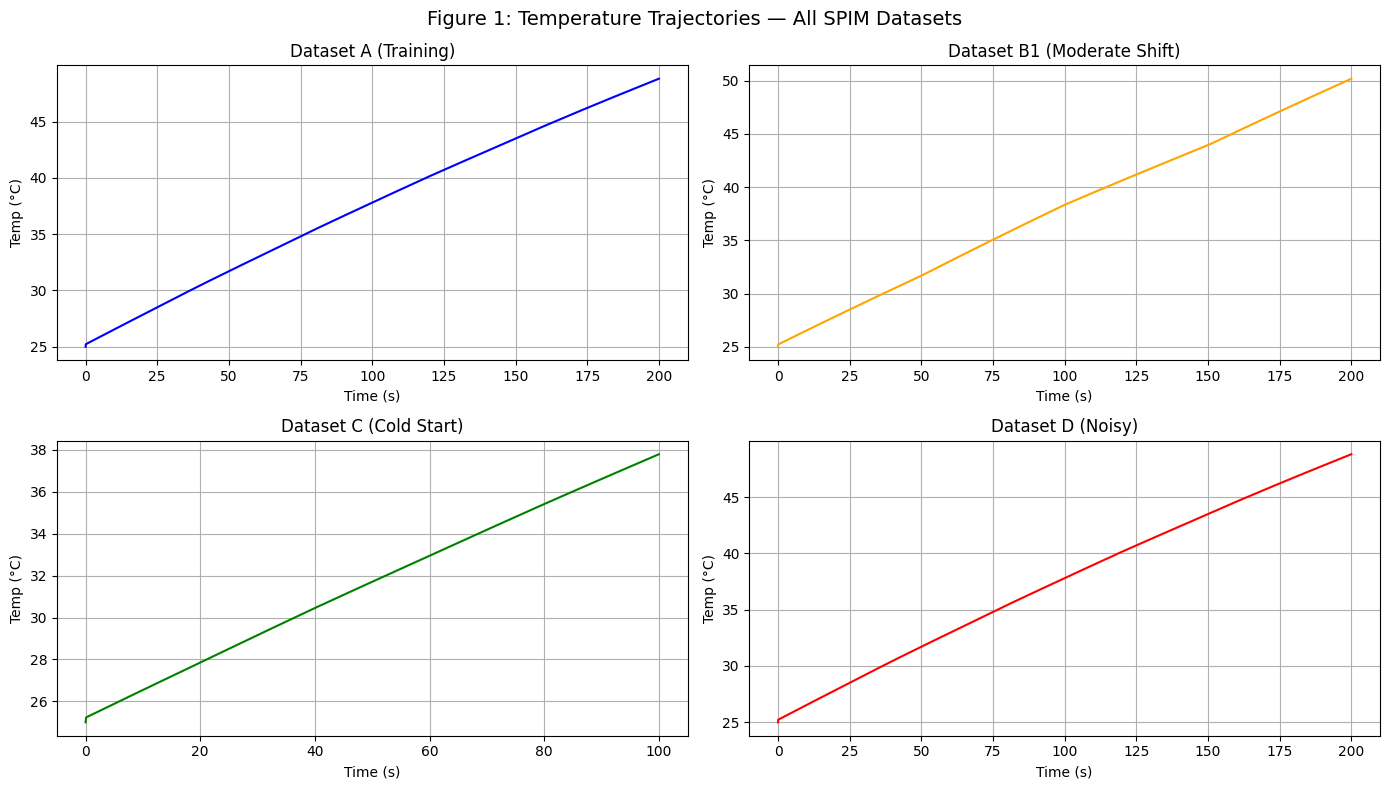

Figure 1 saved.


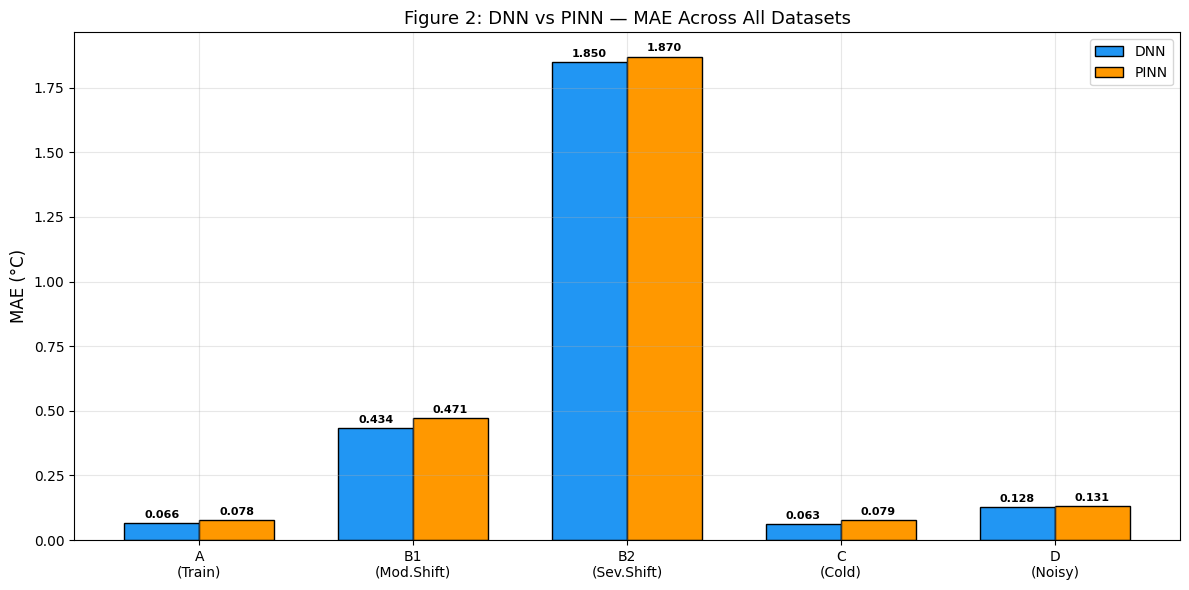

Figure 2 saved.


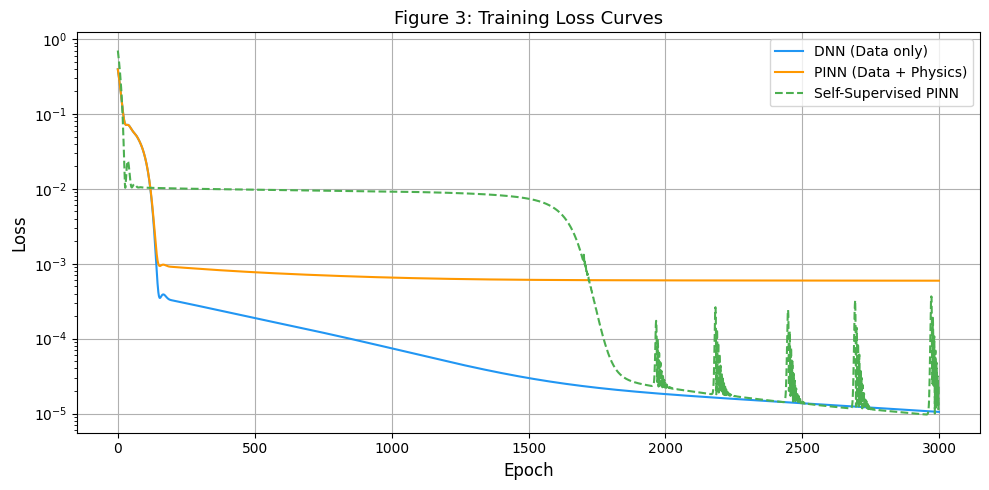

Figure 3 saved.


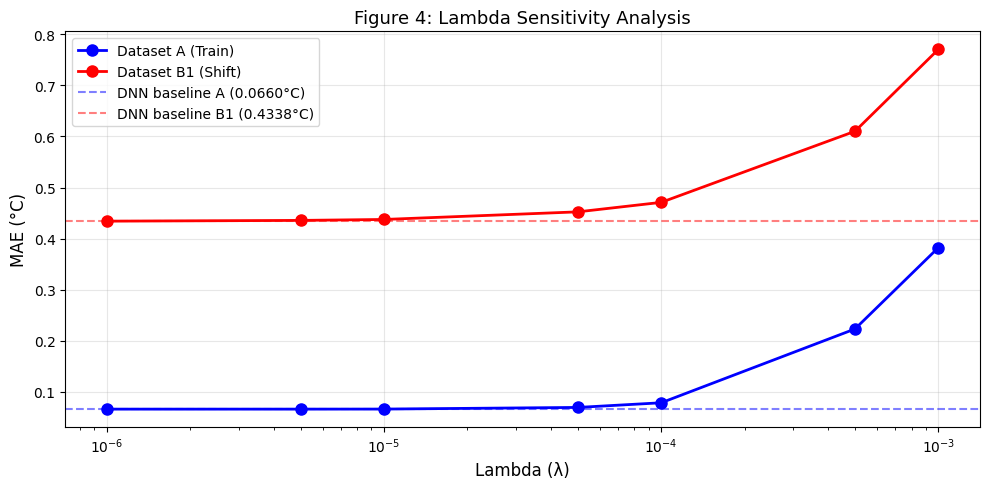

Figure 4 saved.


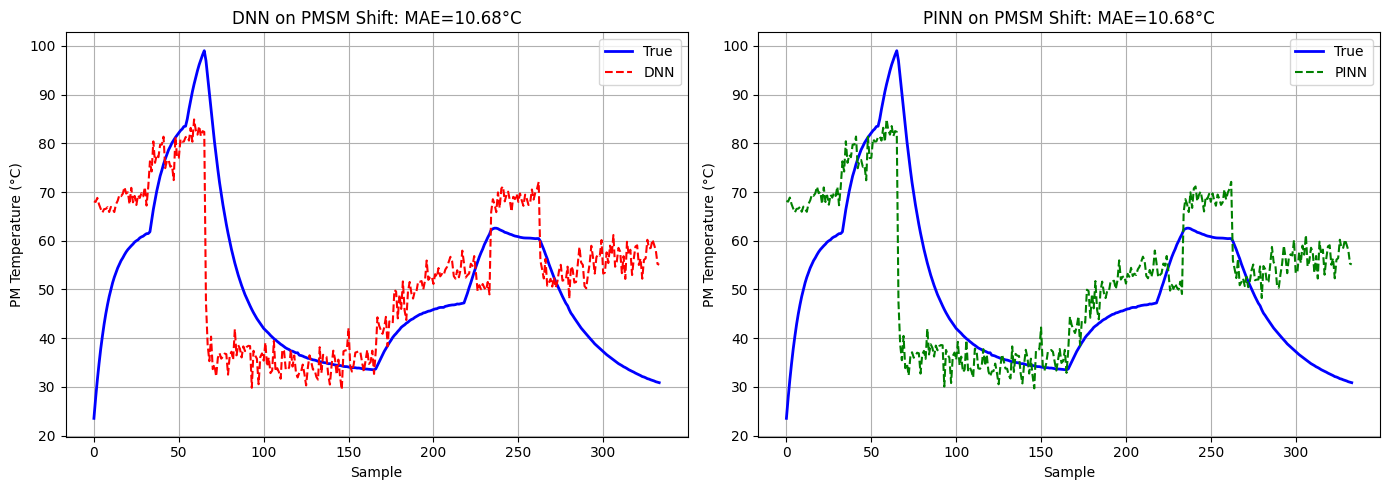

Figure 5 saved.

All figures generated and saved.


In [28]:
# =============================================================
# Cell 14: Generate All Paper Figures
# =============================================================

fig_dir = '/content/'

# --- Figure 1: Temperature Trajectories ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Figure 1: Temperature Trajectories — All SPIM Datasets', fontsize=14)

axes[0,0].plot(df_A['time'], df_A['temperature'], 'b-', linewidth=1.5)
axes[0,0].set_title('Dataset A (Training)'); axes[0,0].set_xlabel('Time (s)'); axes[0,0].set_ylabel('Temp (°C)'); axes[0,0].grid(True)

axes[0,1].plot(df_B['time'], df_B['temperature'], 'orange', linewidth=1.5)
axes[0,1].set_title('Dataset B1 (Moderate Shift)'); axes[0,1].set_xlabel('Time (s)'); axes[0,1].set_ylabel('Temp (°C)'); axes[0,1].grid(True)

axes[1,0].plot(df_C['time'], df_C['temperature'], 'g-', linewidth=1.5)
axes[1,0].set_title('Dataset C (Cold Start)'); axes[1,0].set_xlabel('Time (s)'); axes[1,0].set_ylabel('Temp (°C)'); axes[1,0].grid(True)

axes[1,1].plot(df_D['time'], df_D['temperature'], 'r-', linewidth=1.5)
axes[1,1].set_title('Dataset D (Noisy)'); axes[1,1].set_xlabel('Time (s)'); axes[1,1].set_ylabel('Temp (°C)'); axes[1,1].grid(True)

plt.tight_layout()
plt.savefig(fig_dir + 'fig1_temperature_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

# --- Figure 2: DNN vs PINN MAE Bar Chart ---
fig, ax = plt.subplots(figsize=(12, 6))
dataset_names = ['A\n(Train)', 'B1\n(Mod.Shift)', 'B2\n(Sev.Shift)', 'C\n(Cold)', 'D\n(Noisy)']
dnn_vals  = [mae_dnn['A'], mae_dnn['B'], mae_dnn_B2, mae_dnn['C'], mae_dnn['D']]
pinn_vals = [mae_pinn['A'], mae_pinn['B'], mae_pinn_B2, mae_pinn['C'], mae_pinn['D']]

x = np.arange(len(dataset_names))
width = 0.35
bars1 = ax.bar(x - width/2, dnn_vals,  width, label='DNN',  color='#2196F3', edgecolor='black')
bars2 = ax.bar(x + width/2, pinn_vals, width, label='PINN', color='#FF9800', edgecolor='black')
ax.set_ylabel('MAE (°C)', fontsize=12)
ax.set_title('Figure 2: DNN vs PINN — MAE Across All Datasets', fontsize=13)
ax.set_xticks(x); ax.set_xticklabels(dataset_names)
ax.legend(); ax.grid(True, alpha=0.3)
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig(fig_dir + 'fig2_mae_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

# --- Figure 3: Training Loss Curves ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(losses_dnn,  label='DNN (Data only)',       linewidth=1.5, color='#2196F3')
ax.plot(losses_pinn, label='PINN (Data + Physics)', linewidth=1.5, color='#FF9800')
ax.plot(losses_ss,   label='Self-Supervised PINN',  linewidth=1.5, color='#4CAF50', linestyle='--')
ax.set_yscale('log')
ax.set_xlabel('Epoch', fontsize=12); ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Figure 3: Training Loss Curves', fontsize=13)
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig(fig_dir + 'fig3_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

# --- Figure 4: Lambda Sensitivity ---
fig, ax = plt.subplots(figsize=(10, 5))
lam_vals  = [r['lambda']  for r in results_lambda]
mae_A_lam = [r['mae_A']   for r in results_lambda]
mae_B_lam = [r['mae_B']   for r in results_lambda]

ax.semilogx(lam_vals, mae_A_lam, 'b-o', label='Dataset A (Train)',    linewidth=2, markersize=8)
ax.semilogx(lam_vals, mae_B_lam, 'r-o', label='Dataset B1 (Shift)', linewidth=2, markersize=8)
ax.axhline(y=mae_dnn['A'], color='b', linestyle='--', alpha=0.5, label=f'DNN baseline A ({mae_dnn["A"]:.4f}°C)')
ax.axhline(y=mae_dnn['B'], color='r', linestyle='--', alpha=0.5, label=f'DNN baseline B1 ({mae_dnn["B"]:.4f}°C)')
ax.set_xlabel('Lambda (λ)', fontsize=12); ax.set_ylabel('MAE (°C)', fontsize=12)
ax.set_title('Figure 4: Lambda Sensitivity Analysis', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir + 'fig4_lambda_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

# --- Figure 5: PMSM Validation ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
_, _, _, pred_dnn_te2,  true_te2  = evaluate(dnn_p,  X_te_t, y_te_t, sc_y_p)
_, _, _, pred_pinn_te2, _         = evaluate(pinn_p, X_te_t, y_te_t, sc_y_p)

ax1.plot(true_te2,     'b-',  label='True',  linewidth=2)
ax1.plot(pred_dnn_te2, 'r--', label='DNN',   linewidth=1.5)
ax1.set_title(f'DNN on PMSM Shift: MAE={mae_dnn_pte:.2f}°C')
ax1.set_xlabel('Sample'); ax1.set_ylabel('PM Temperature (°C)')
ax1.legend(); ax1.grid(True)

ax2.plot(true_te2,      'b-',  label='True',  linewidth=2)
ax2.plot(pred_pinn_te2, 'g--', label='PINN',  linewidth=1.5)
ax2.set_title(f'PINN on PMSM Shift: MAE={mae_pinn_pte:.2f}°C')
ax2.set_xlabel('Sample'); ax2.set_ylabel('PM Temperature (°C)')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig(fig_dir + 'fig5_pmsm_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

print('\nAll figures generated and saved.')

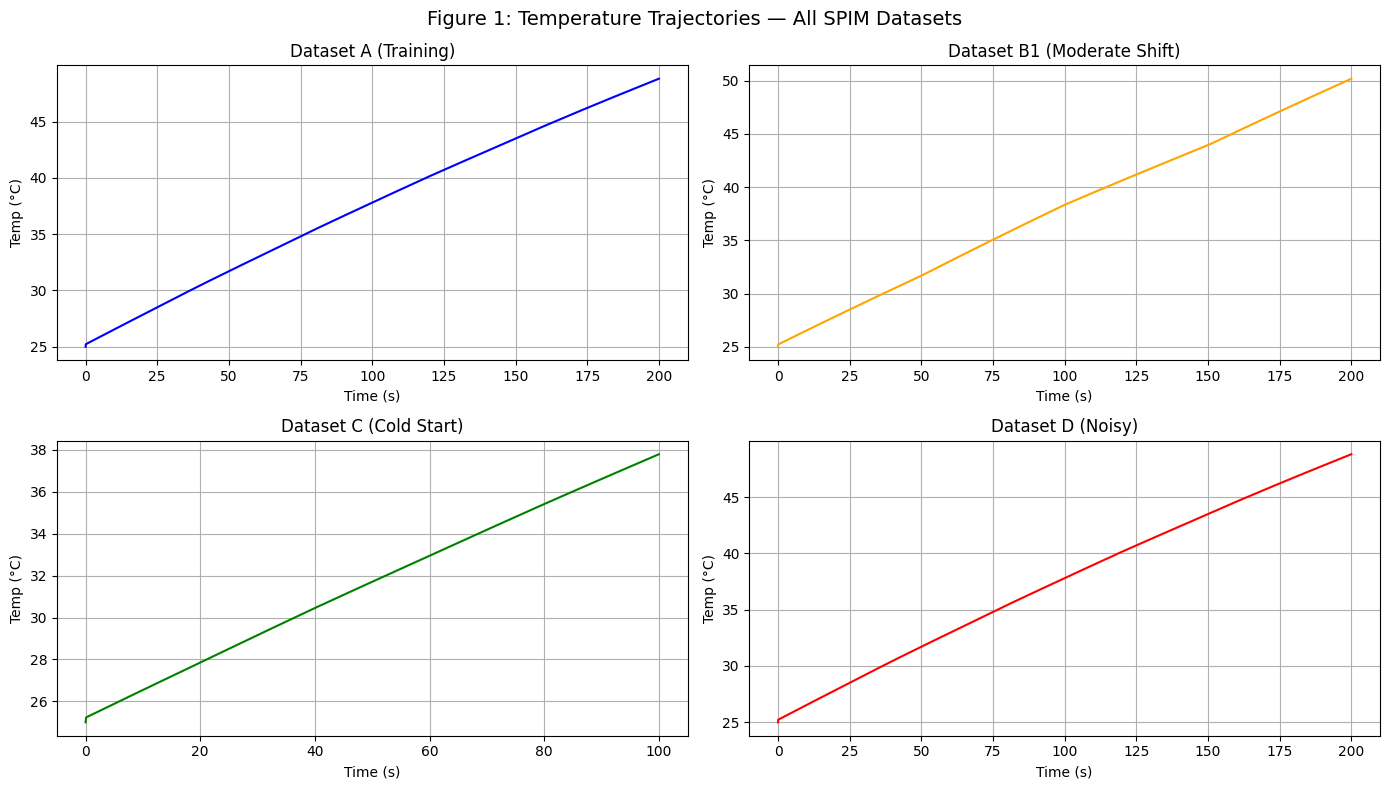

Figure 1 saved.


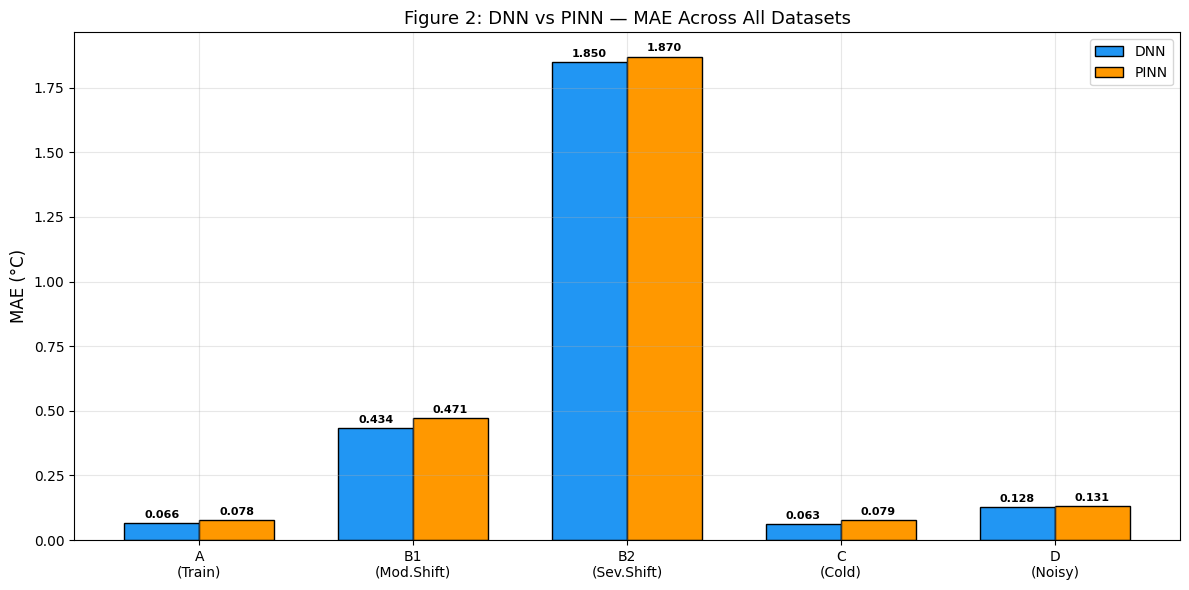

Figure 2 saved.


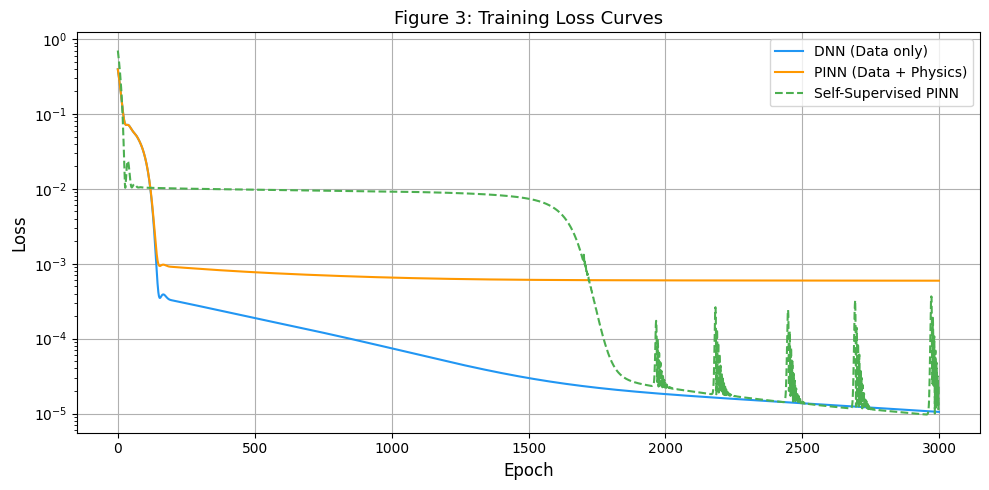

Figure 3 saved.


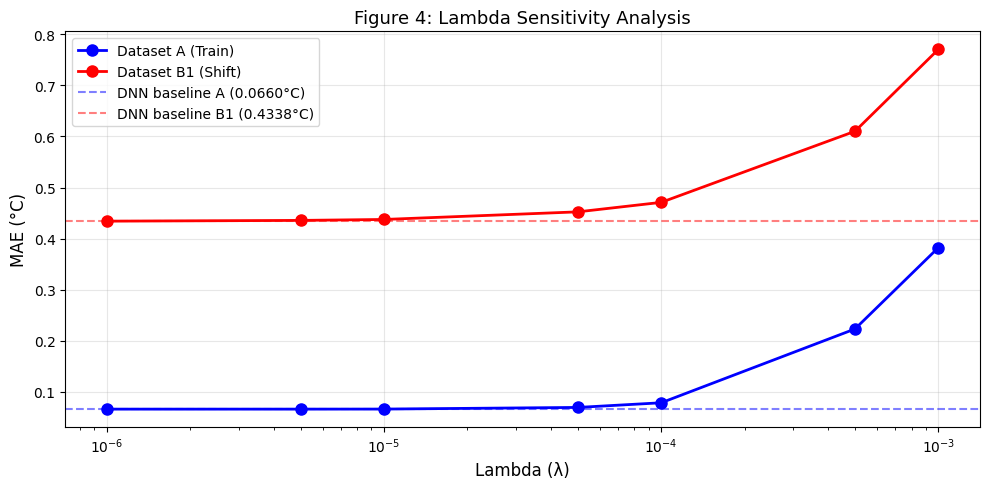

Figure 4 saved.


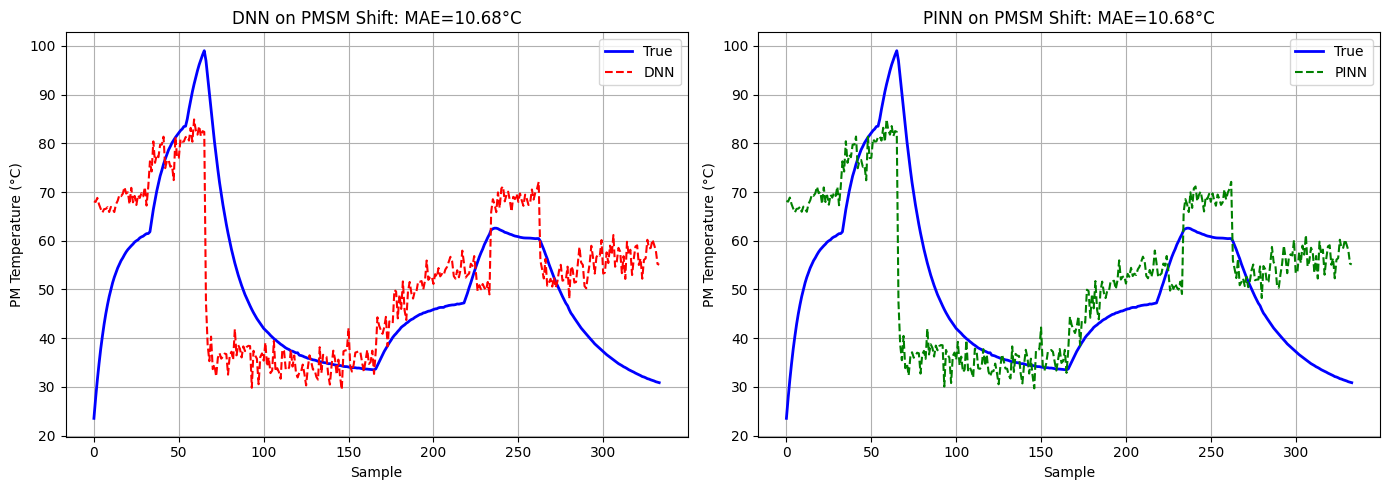

Figure 5 saved.

All figures generated and saved.


In [29]:
# =============================================================
# Cell 14: Generate All Paper Figures
# =============================================================

fig_dir = '/content/'

# --- Figure 1: Temperature Trajectories ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Figure 1: Temperature Trajectories — All SPIM Datasets', fontsize=14)

axes[0,0].plot(df_A['time'], df_A['temperature'], 'b-', linewidth=1.5)
axes[0,0].set_title('Dataset A (Training)'); axes[0,0].set_xlabel('Time (s)'); axes[0,0].set_ylabel('Temp (°C)'); axes[0,0].grid(True)

axes[0,1].plot(df_B['time'], df_B['temperature'], 'orange', linewidth=1.5)
axes[0,1].set_title('Dataset B1 (Moderate Shift)'); axes[0,1].set_xlabel('Time (s)'); axes[0,1].set_ylabel('Temp (°C)'); axes[0,1].grid(True)

axes[1,0].plot(df_C['time'], df_C['temperature'], 'g-', linewidth=1.5)
axes[1,0].set_title('Dataset C (Cold Start)'); axes[1,0].set_xlabel('Time (s)'); axes[1,0].set_ylabel('Temp (°C)'); axes[1,0].grid(True)

axes[1,1].plot(df_D['time'], df_D['temperature'], 'r-', linewidth=1.5)
axes[1,1].set_title('Dataset D (Noisy)'); axes[1,1].set_xlabel('Time (s)'); axes[1,1].set_ylabel('Temp (°C)'); axes[1,1].grid(True)

plt.tight_layout()
plt.savefig(fig_dir + 'fig1_temperature_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

# --- Figure 2: DNN vs PINN MAE Bar Chart ---
fig, ax = plt.subplots(figsize=(12, 6))
dataset_names = ['A\n(Train)', 'B1\n(Mod.Shift)', 'B2\n(Sev.Shift)', 'C\n(Cold)', 'D\n(Noisy)']
dnn_vals  = [mae_dnn['A'], mae_dnn['B'], mae_dnn_B2, mae_dnn['C'], mae_dnn['D']]
pinn_vals = [mae_pinn['A'], mae_pinn['B'], mae_pinn_B2, mae_pinn['C'], mae_pinn['D']]

x = np.arange(len(dataset_names))
width = 0.35
bars1 = ax.bar(x - width/2, dnn_vals,  width, label='DNN',  color='#2196F3', edgecolor='black')
bars2 = ax.bar(x + width/2, pinn_vals, width, label='PINN', color='#FF9800', edgecolor='black')
ax.set_ylabel('MAE (°C)', fontsize=12)
ax.set_title('Figure 2: DNN vs PINN — MAE Across All Datasets', fontsize=13)
ax.set_xticks(x); ax.set_xticklabels(dataset_names)
ax.legend(); ax.grid(True, alpha=0.3)
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig(fig_dir + 'fig2_mae_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

# --- Figure 3: Training Loss Curves ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(losses_dnn,  label='DNN (Data only)',       linewidth=1.5, color='#2196F3')
ax.plot(losses_pinn, label='PINN (Data + Physics)', linewidth=1.5, color='#FF9800')
ax.plot(losses_ss,   label='Self-Supervised PINN',  linewidth=1.5, color='#4CAF50', linestyle='--')
ax.set_yscale('log')
ax.set_xlabel('Epoch', fontsize=12); ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Figure 3: Training Loss Curves', fontsize=13)
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig(fig_dir + 'fig3_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

# --- Figure 4: Lambda Sensitivity ---
fig, ax = plt.subplots(figsize=(10, 5))
lam_vals  = [r['lambda']  for r in results_lambda]
mae_A_lam = [r['mae_A']   for r in results_lambda]
mae_B_lam = [r['mae_B']   for r in results_lambda]

ax.semilogx(lam_vals, mae_A_lam, 'b-o', label='Dataset A (Train)',    linewidth=2, markersize=8)
ax.semilogx(lam_vals, mae_B_lam, 'r-o', label='Dataset B1 (Shift)', linewidth=2, markersize=8)
ax.axhline(y=mae_dnn['A'], color='b', linestyle='--', alpha=0.5, label=f'DNN baseline A ({mae_dnn["A"]:.4f}°C)')
ax.axhline(y=mae_dnn['B'], color='r', linestyle='--', alpha=0.5, label=f'DNN baseline B1 ({mae_dnn["B"]:.4f}°C)')
ax.set_xlabel('Lambda (λ)', fontsize=12); ax.set_ylabel('MAE (°C)', fontsize=12)
ax.set_title('Figure 4: Lambda Sensitivity Analysis', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir + 'fig4_lambda_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

# --- Figure 5: PMSM Validation ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
_, _, _, pred_dnn_te2,  true_te2  = evaluate(dnn_p,  X_te_t, y_te_t, sc_y_p)
_, _, _, pred_pinn_te2, _         = evaluate(pinn_p, X_te_t, y_te_t, sc_y_p)

ax1.plot(true_te2,     'b-',  label='True',  linewidth=2)
ax1.plot(pred_dnn_te2, 'r--', label='DNN',   linewidth=1.5)
ax1.set_title(f'DNN on PMSM Shift: MAE={mae_dnn_pte:.2f}°C')
ax1.set_xlabel('Sample'); ax1.set_ylabel('PM Temperature (°C)')
ax1.legend(); ax1.grid(True)

ax2.plot(true_te2,      'b-',  label='True',  linewidth=2)
ax2.plot(pred_pinn_te2, 'g--', label='PINN',  linewidth=1.5)
ax2.set_title(f'PINN on PMSM Shift: MAE={mae_pinn_pte:.2f}°C')
ax2.set_xlabel('Sample'); ax2.set_ylabel('PM Temperature (°C)')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig(fig_dir + 'fig5_pmsm_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

print('\nAll figures generated and saved.')

In [30]:
from google.colab import files

figures = [
    'fig1_temperature_trajectories.png',
    'fig2_mae_comparison.png',
    'fig3_training_loss.png',
    'fig4_lambda_sensitivity.png',
    'fig5_pmsm_validation.png'
]

for fig in figures:
    files.download(fig)
    print(f'Downloaded: {fig}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: fig1_temperature_trajectories.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: fig4_lambda_sensitivity.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: fig5_pmsm_validation.png
